<a href="https://colab.research.google.com/github/xaznweix/CIS9760-project1/blob/main/Insurance_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this project, I aim to conduct a Monte Carlo simulation on an insurance claims dataset, specifically bodily injury claims. The main idea of this project was to identify whether having attorney representation or the claimant’s age played a role in the expected loss of the insurance claim.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
url = "https://raw.githubusercontent.com/xaznweix/Insurance-dataset/f5513ce5989935009d1754ad018f09bf8fff1f14/AutoBi.csv"
AutoBI = pd.read_csv(url)
AutoBI.head()

,Index,CASENUM,ATTORNEY,CLMSEX,MARITAL,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,1,5,1,1.0,NaN,2.0,1.0,50.0,34.940
1,2,13,2,2.0,2.0,1.0,1.0,28.0,10.892
2,3,66,2,1.0,2.0,2.0,1.0,5.0,0.330
3,4,71,1,1.0,1.0,2.0,2.0,32.0,11.037
4,5,96,2,1.0,4.0,2.0,1.0,30.0,0.138


In [5]:
url = "https://raw.githubusercontent.com/xaznweix/Insurance-dataset/fd84bba53fd518b05322d1a59fd73fba08c8e193/AutoClaims.csv"
AutoClaims = pd.read_csv(url)

AutoClaims.head()

,Index,STATE,CLASS,GENDER,AGE,PAID
0,1,STATE 14,C6,M,97,1134.44
1,2,STATE 15,C6,M,96,3761.24
2,3,STATE 15,C11,M,95,7842.31
3,4,STATE 15,F6,F,95,2384.67
4,5,STATE 15,F6,M,95,650.00


In [6]:
url = "https://raw.githubusercontent.com/xaznweix/Insurance-dataset/main/AutoCollision.csv"
AutoCol = pd.read_csv(url)
AutoCol.head()

,Index,Age,Vehicle_Use,Severity,Claim_Count
0,1,A,Pleasure,250.48,21
1,2,A,DriveShort,274.78,40
2,3,A,DriveLong,244.52,23
3,4,A,Business,797.80,5
4,5,B,Pleasure,213.71,63


In [7]:
# ── Clean: drop nulls in key columns ────────────────────────────────
loss     = AutoBI["LOSS"].dropna()
paid     = AutoClaims["PAID"].dropna()
severity = AutoCol["Severity"].dropna()

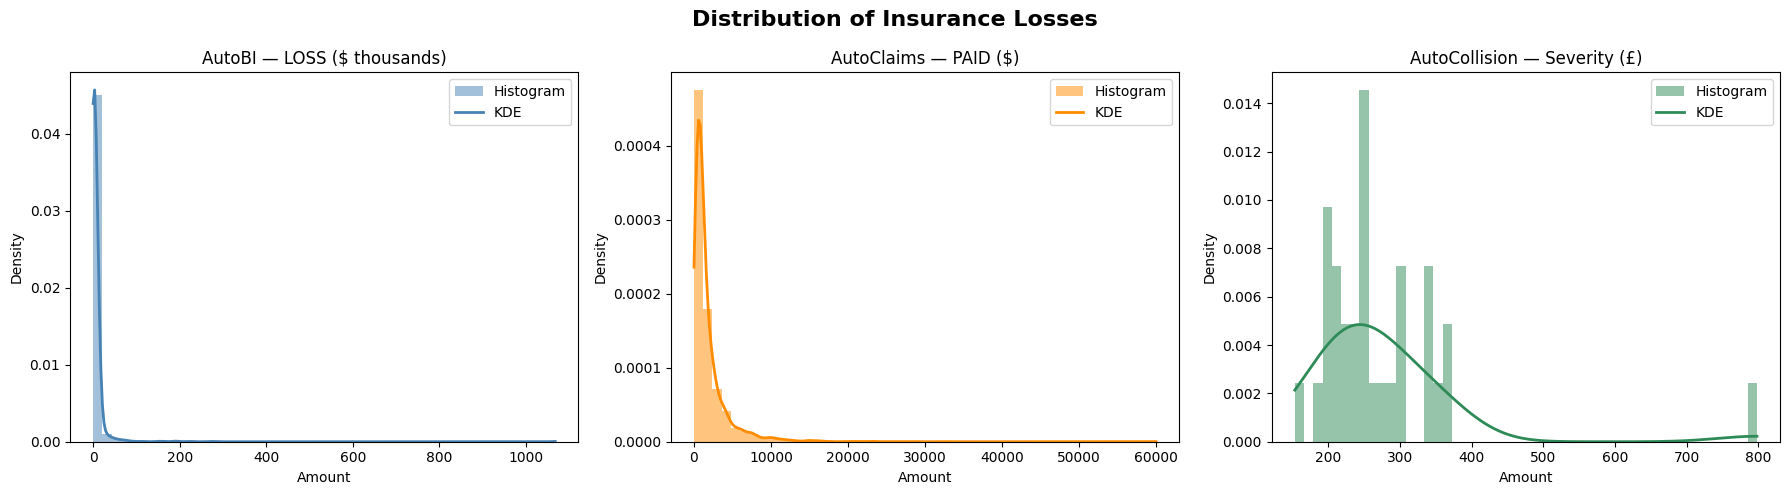

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribution of Insurance Losses", fontsize=16, fontweight="bold")

datasets = [
    (loss,     "AutoBI — LOSS ($ thousands)", "steelblue"),
    (paid,     "AutoClaims — PAID ($)",        "darkorange"),
    (severity, "AutoCollision — Severity (£)", "seagreen"),
]

for ax, (data, title, color) in zip(axes, datasets):
    ax.hist(data, bins=50, density=True, alpha=0.5, color=color, label="Histogram")
    kde = stats.gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 300)
    ax.plot(x, kde(x), color=color, linewidth=2, label="KDE")
    ax.set_title(title)
    ax.set_xlabel("Amount")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.savefig("distributions_hist_kde.png", dpi=150)
plt.show()

From the plot, it looks like AutoBI is extremely right skewed.
AutoClaims is also extremely right skewed as well.
AutoCollision is mild skewed.

The implied mean for lognormal is e^( mu + 0.5*sigma^2)

In [9]:
# for this we are fitting a lognormal distribution on AutoBI loss because it is right skewed.

loss = loss[loss > 0]  # lognormal requires strictly positive values

# ── Fit lognormal ──────────────────────────────────────────────────
# scipy returns (shape=sigma, loc=shift, scale=exp(mu))
sigma, loc, scale = stats.lognorm.fit(loss, floc=0)  # floc=0 fixes location at 0

mu = np.log(scale)   # convert scale back to mu

print(f"Fitted μ (mu):    {mu:.4f}")
print(f"Fitted σ (sigma): {sigma:.4f}")
print(f"Implied median:   ${np.exp(mu):.2f}k")
print(f"Implied mean:     ${np.exp(mu + 0.5*sigma**2):.2f}k")

Fitted μ (mu):    0.5567
Fitted σ (sigma): 1.4779
Implied median:   $1.74k
Implied mean:     $5.20k


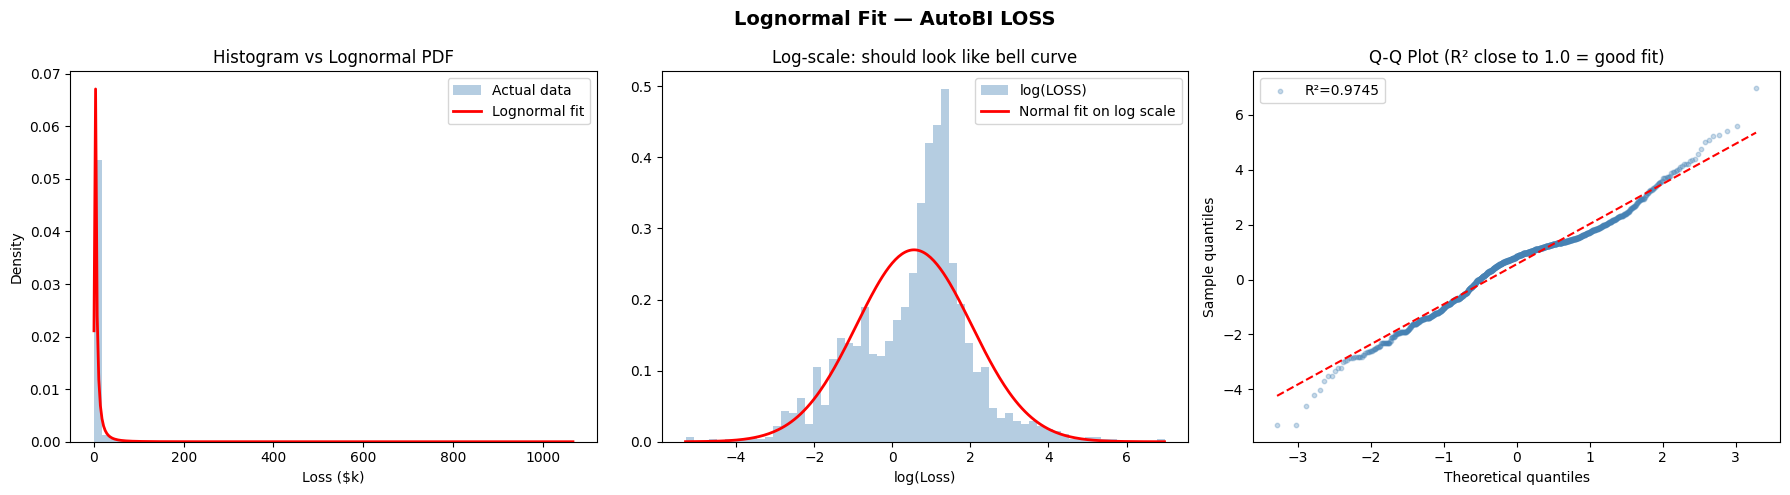

In [10]:
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Lognormal Fit — AutoBI LOSS", fontsize=14, fontweight="bold")

x = np.linspace(loss.min(), loss.max(), 300)
pdf_fitted = stats.lognorm.pdf(x, s=sigma, loc=0, scale=scale)

# Plot 1 — Histogram vs fitted curve
axes[0].hist(loss, bins=60, density=True, alpha=0.4,
             color="steelblue", label="Actual data")
axes[0].plot(x, pdf_fitted, "r-", linewidth=2, label="Lognormal fit")
axes[0].set_title("Histogram vs Lognormal PDF")
axes[0].set_xlabel("Loss ($k)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Plot 2 — Same on log scale (more informative)
log_loss = np.log(loss)
axes[1].hist(log_loss, bins=60, density=True, alpha=0.4,
             color="steelblue", label="log(LOSS)")
x_log = np.linspace(log_loss.min(), log_loss.max(), 300)
axes[1].plot(x_log, stats.norm.pdf(x_log, mu, sigma),
             "r-", linewidth=2, label="Normal fit on log scale")
axes[1].set_title("Log-scale: should look like bell curve")
axes[1].set_xlabel("log(Loss)")
axes[1].legend()

# Plot 3 — Q-Q plot (definitive goodness-of-fit test)
(osm, osr), (slope, intercept, r) = stats.probplot(log_loss, dist="norm")
axes[2].scatter(osm, osr, alpha=0.3, color="steelblue", s=10, label=f"R²={r**2:.4f}")
axes[2].plot(osm, slope*np.array(osm)+intercept, "r--", linewidth=1.5)
axes[2].set_title("Q-Q Plot (R² close to 1.0 = good fit)")
axes[2].set_xlabel("Theoretical quantiles")
axes[2].set_ylabel("Sample quantiles")
axes[2].legend()

plt.tight_layout()
plt.show()

In the first figure, we see that the lognormal fit is close to the actual data.
In the second figure, we see that the distribution much more symmetric after the log transformation and it looks approximately bell shaped.
In the third figure, we see that points mostly follow a straight line and that the R^2 value is pretty close to 1.


In [11]:
# Fit separate distributions per group
attorney     = AutoBI[AutoBI["ATTORNEY"] == 1]["LOSS"]
no_attorney  = AutoBI[AutoBI["ATTORNEY"] == 2]["LOSS"]

# Fit lognormal to each
sig_att,  _, scale_att  = stats.lognorm.fit(attorney,    floc=0)
sig_natt, _, scale_natt = stats.lognorm.fit(no_attorney, floc=0)

In [12]:
# Interpret the results
print("=== Attorney-represented claims ===")
print(f"sigma:          {sig_att:.4f}")
print(f"median loss:    ${np.exp(np.log(scale_att)):.2f}k")
print(f"implied mean:   ${np.exp(np.log(scale_att) + 0.5*sig_att**2):.2f}k")

print("\n=== Non-attorney claims ===")
print(f"sigma:          {sig_natt:.4f}")
print(f"median loss:    ${np.exp(np.log(scale_natt)):.2f}k")
print(f"implied mean:   ${np.exp(np.log(scale_natt) + 0.5*sig_natt**2):.2f}k")

=== Attorney-represented claims ===
sigma:          1.2448
median loss:    $3.49k
implied mean:   $7.58k

=== Non-attorney claims ===
sigma:          1.3482
median loss:    $0.84k
implied mean:   $2.10k


It looks like the attorney represented claims have a higher median loss and a higher implied mean.
The surprising thing is that the sigma (standard deviation) is higher for the non-attorney claims.
We will try to simulate monte carlo simulation for the loss when a client is represented by an attorney.

In [13]:
n_simulations = 10_000

# What fraction of claims involve attorneys?
p_attorney = len(attorney) / len(AutoBI)
print(f"Attorney involvement rate: {p_attorney:.1%}")

total_losses = []

for _ in range(n_simulations):
    n_total = 100  # expected claims in a year

    # Split into attorney vs non-attorney
    n_att  = np.random.binomial(n_total, p_attorney)
    n_natt = n_total - n_att

    # Draw losses from each population separately
    losses_att  = stats.lognorm.rvs(s=sig_att,  scale=scale_att,  size=n_att)
    losses_natt = stats.lognorm.rvs(s=sig_natt, scale=scale_natt, size=n_natt)

    total = np.sum(losses_att) + np.sum(losses_natt)
    total_losses.append(total)

total_losses = np.array(total_losses)

print(f"\nMonte Carlo Results (split by attorney)")
print(f"Mean expected loss:     ${total_losses.mean():.2f}k")
print(f"VaR 95%:                ${np.percentile(total_losses, 95):.2f}k")
print(f"VaR 99%:                ${np.percentile(total_losses, 99):.2f}k")
cvar = total_losses[total_losses >= np.percentile(total_losses, 95)].mean()
print(f"Expected Shortfall:     ${cvar:.2f}k")

Attorney involvement rate: 51.1%

Monte Carlo Results (split by attorney)
Mean expected loss:     $488.96k
VaR 95%:                $688.10k
VaR 99%:                $834.60k
Expected Shortfall:     $781.26k


### Monte Carlo Simulation Results

Based on a simulation with **100 expected claims**, the results are:

- **Mean annual aggregate loss:** \$489.38k  

- **95% Value at Risk (VaR):** \$683.61k  

### Interpretation

- In **95% of simulated years**, total losses are expected to be **below \$683.61k**.  
- In the **worst 5% of years**, losses exceed this level.

In [14]:
sig_att,  _, scale_att  = stats.lognorm.fit(attorney,    floc=0)
sig_natt, _, scale_natt = stats.lognorm.fit(no_attorney, floc=0)

print("=== Raw scipy output ===")
print(f"Attorney    | sig={sig_att:.4f}  scale={scale_att:.4f}")
print(f"No attorney | sig={sig_natt:.4f} scale={scale_natt:.4f}")

print("\n=== What these imply ===")
print(f"Attorney    | median=${scale_att:.2f}k  mean=${np.exp(np.log(scale_att)+0.5*sig_att**2):.2f}k")
print(f"No attorney | median=${scale_natt:.2f}k mean=${np.exp(np.log(scale_natt)+0.5*sig_natt**2):.2f}k")

print("\n=== Actual data means ===")
print(f"Attorney    | mean=${attorney.mean():.2f}k")
print(f"No attorney | mean=${no_attorney.mean():.2f}k")

=== Raw scipy output ===
Attorney    | sig=1.2448  scale=3.4930
No attorney | sig=1.3482 scale=0.8445

=== What these imply ===
Attorney    | median=$3.49k  mean=$7.58k
No attorney | median=$0.84k mean=$2.10k

=== Actual data means ===
Attorney    | mean=$9.86k
No attorney | mean=$1.86k


In the cell below, we can verify how close our simulation results match with computing the expected loss manually (excepted value of our binomial distribution). The difference between those two result is $106.39k.

In [15]:
# Verify by computing expected loss manually
expected_manual = (n_total * p_attorney      * attorney.mean()) + \
                  (n_total * (1-p_attorney)  * no_attorney.mean())

print(f"Manual expected loss:      ${expected_manual:.2f}k")
print(f"Simulation expected loss:  ${total_losses.mean():.2f}k")
print(f"Difference:                ${abs(expected_manual - total_losses.mean()):.2f}k")

Manual expected loss:      $595.35k
Simulation expected loss:  $488.96k
Difference:                $106.39k


In [16]:
import ipywidgets as widgets
from ipywidgets import interact

In [17]:
def simulate(p_attorney):
    n_sim = 2000
    n_claims = 1000

    total_losses = []

    for _ in range(n_sim):
        attorney_flags = np.random.rand(n_claims) < p_attorney

        attorney_losses = np.random.choice(attorney , size=attorney_flags.sum())
        non_attorney_losses = np.random.choice(no_attorney, size=(~attorney_flags).sum())

        total_loss = attorney_losses.sum() + non_attorney_losses.sum()
        total_losses.append(total_loss)

    # plot
    plt.hist(total_losses, bins=40)
    plt.title(f"Loss Distribution (Attorney % = {p_attorney:.0%})")
    plt.show()

    print("Mean:", np.mean(total_losses))
    print("95th percentile:", np.percentile(total_losses, 95))

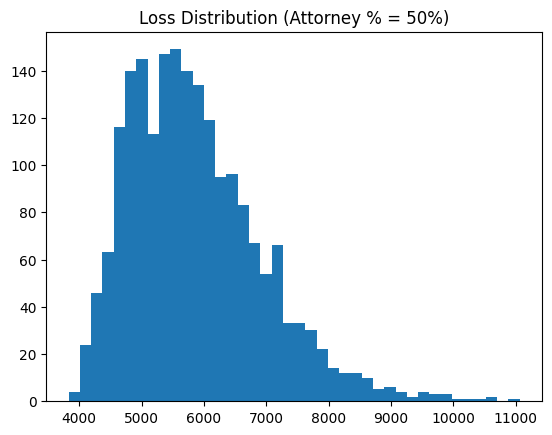

Mean: 5869.554945
95th percentile: 7833.2495499999995


In [18]:
simulate(0.5)

In [19]:
interact(simulate, p_attorney=widgets.FloatSlider(min=0.0, max=1.0, step=0.05, value=0.3))

interactive(children=(FloatSlider(value=0.3, description='p_attorney', max=1.0, step=0.05), Output()), _dom_cl…

<function __main__.simulate(p_attorney)>